In [52]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

In [54]:
# Load data
df_A = pd.read_csv("data/AAPL.csv")
df_B = pd.read_csv("data/MSFT.csv")

# Rename columns
df_A.columns = ["datetime", "open", "high", "low", "close", "volume"]
df_B.columns = ["datetime", "open", "high", "low", "close", "volume"]

# Parse datetime
df_A["datetime"] = pd.to_datetime(df_A["datetime"])
df_B["datetime"] = pd.to_datetime(df_B["datetime"])

# Set datetime as index
df_A = df_A.set_index("datetime").sort_index()
df_B = df_B.set_index("datetime").sort_index()

# Create a new DF that merges close prices
# Also remove NA values
df = pd.DataFrame({
    "A_close": df_A["close"],
    "B_close": df_B["close"]
}).dropna()


# Remove first and last 15 min
# since the market is noisy during these periods. 
df = df.between_time("09:45", "15:45").copy()

# we use log prices so that data manipulation 
# and interpretation will be easier for us
df["logA"] = np.log(df["A_close"])
df["logB"] = np.log(df["B_close"])

# display the first couple lines of DF
df.head()

,A_close,B_close,logA,logB
datetime,,,,
2022-09-30 09:45:00,142.0900,240.0300,4.956461,5.480764
2022-09-30 09:46:00,141.9250,239.5000,4.955299,5.478553
2022-09-30 09:47:00,142.0616,239.7700,4.956261,5.479680
2022-09-30 09:48:00,141.4900,238.6101,4.952229,5.474831
2022-09-30 09:49:00,141.9700,238.9300,4.955616,5.476171


### Engle–Granger Two-Step Cointegration Test

The Engle–Granger method tests whether two non-stationary series share a stable long-run relationship.

**Step 1: Run a regression**

Regress one log price series on the other:

$$
\log(A_t) = \alpha + \beta \log(B_t) + \epsilon_t
$$

where $\epsilon_t$ is the residual from the regression.

**Step 2: Test whether the residuals are stationary**

After estimating the regression, test the residual series $\epsilon_t$ for a unit root.

**Hypotheses**

- **Null hypothesis:** the residual is non-stationary  
  $\rightarrow$ no cointegration

- **Alternative hypothesis:** the residual is stationary  
  $\rightarrow$ cointegration

In [57]:
# full-sample cointegration check
# to check if a spread-based mean-reversion strategy may make sense
score, pvalue, _ = coint(df["logA"], df["logB"]) # perform cointegration test
print("Full-sample cointegration p-value:", pvalue)

if pvalue < 0.05:
    print("Full sample suggests cointegration.")
else:
    print("Full sample does NOT strongly support cointegration.")

Full-sample cointegration p-value: 0.06901729475976645
Full sample does NOT strongly support cointegration.


Even though they are not cointegrated over this long period, what if they do integrate over specific short time interval? 

We try to use rolling hedge ratio which assumes that the relationship between the two assets fluctuate. And this is also a more realistics
approach because if we set a fixed hedge ratio, our model will failed to capture opprtunities and may experience losses. 

In [63]:
# rolling hedge ratio and intercept
lookback = 3 * 390   # 3 trading days of 1-minute bars
                    # each regression uses 1170 one-minute bars

# Storage arrays 
alphas = np.full(len(df), np.nan) # we create alphas, which is a vector of length the same as df and filled with na values
betas = np.full(len(df), np.nan) # we create betas, which is a vector of length the same as df and filled with na values

for i in range(lookback, len(df)):
    # define dependent variables
    y = df["logA"].iloc[i - lookback:i] # y in past 3 trading days
    x = df["logB"].iloc[i - lookback:i] # x in past 3 trading days
    X = sm.add_constant(x) # adding constant terms, so that the regression is alpha + beta*logB
    model = sm.OLS(y, X).fit() # fit OLS
    # store the values of alphas and betas
    alphas[i] = model.params.iloc[0] 
    betas[i] = model.params.iloc[1]

# put alpha and beta into the dataframe
df["alpha"] = alphas
df["beta"] = betas

We are interested in the residual, defined as:

$$
\hat{\epsilon}_t = \log(A_t) - \hat{\alpha} - \hat{\beta}\log(B_t)
$$

### Interpreting the Residual Spread

The residual is the **spread** we are interested in. It measures how far the relationship between \(A\) and \(B\) deviates from its estimated long-run equilibrium.

- If the residual is **near 0**, the pair is behaving normally and moving closely together.
- If the residual is **positive**, \(A\) is relatively high compared with \(B\).
- If the residual is **negative**, \(A\) is relatively low compared with \(B\).

In other words, the residual tells us whether the pair has moved away from its usual relationship, which is the key signal in a mean-reversion strategy.

We want to know if the spread is stationary, mean-reverting, or temporarily dislocated but not permanently drifting

In [69]:
# construct rolling residual spread
df["spread"] = df["logA"] - df["alpha"] - df["beta"] * df["logB"]

## Half-life Diagnostic

If the spread gets pushed away from equilibrium, how quickly does it tend to come back?
To answer this question, we compute half-life to measure spread quality. 

In [73]:
# optional half-life diagnostic
spread = df["spread"].dropna().copy()

spread_lag = spread.shift(1) # lagged spread
spread_ret = spread - spread_lag # spread change

# build regression dataset that consists of spread data
hl_df = pd.DataFrame({
    "spread_ret": spread_ret,
    "spread_lag": spread_lag
}).dropna()

# OLS fit
X = sm.add_constant(hl_df["spread_lag"])
hl_model = sm.OLS(hl_df["spread_ret"], X).fit()

# find lambda coefficient, which is the coefficient of spread_lag
lambda_coef = hl_model.params["spread_lag"]


### Half-Life of Mean Reversion

Mathematically, the half-life of mean reversion is:

$$
\text{Half-life} = -\frac{\ln(2)}{\lambda}
$$

This formula comes from **continuous-time mean reversion**.

If a deviation decays exponentially as

$$
s_t \approx s_0 e^{\lambda t}
$$

with

$$
\lambda < 0
$$

then the half-life is the time required for the deviation to shrink to **half** of its original size.

Set

$$
\frac{s_t}{s_0} = \frac{1}{2}
$$

Then

$$
e^{\lambda t_{1/2}} = \frac{1}{2}
$$

Taking logs on both sides gives

$$
\lambda t_{1/2} = \ln\left(\frac{1}{2}\right) = -\ln(2)
$$

So

$$
t_{1/2} = -\frac{\ln(2)}{\lambda}
$$

This is exactly the half-life formula used in mean-reversion analysis.

In [76]:
# if lambda is negative, then there is a mean-reverting tendency
if lambda_coef < 0:
    halflife = -np.log(2) / lambda_coef
    print("Estimated half-life:", halflife)
# if lambda is non-negative, no meaningful mean-reversion in this setup
else:
    halflife = np.nan
    print("Half-life not meaningful because mean reversion coefficient is non-negative.")

Estimated half-life: 282.2188515056148


It takes about 282 bars to shrink the deviation by half. 

Next, we want a specifiFor an intraday strategy, the rolling window should be for spread mean and spread standard deviation.

This window should have this characteristics:

- **long enough** to estimate the mean and standard deviation reasonably well
- **short enough** to adapt to changing intraday market conditions

A **240-minute window** should be more practical here:

- it smooths out noise better than a very short window, such as **20** or **30** bars
- it adapts faster than a very long window, such as **780** or **1170** bars



In [81]:
# rolling z-score with a fixed intraday window
z_window = 240 # about 4 trading hours

df["spread_mean"] = df["spread"].rolling(z_window).mean() # average spread over the past 240 days
df["spread_std"] = df["spread"].rolling(z_window).std() # std spread over the past 240 days

# how many rolling standard deviations the current spread is away from its recent mean
df["zscore"] = (df["spread"] - df["spread_mean"]) / df["spread_std"] 

In [85]:
# rolling cointegration filter
# We want to study whether the pair relationship is still valid in a rolling situation

coint_lookback = 3 * 390      # 3 trading days
retest_freq = 30              # retest every 30 minutes
pvalue_threshold = 0.10       # we can have different values for p-value: 0.05 or 0.10

coint_flag = np.full(len(df), np.nan)
coint_pvals = np.full(len(df), np.nan)

# we use a range loop to check rolling cointegration
for i in range(coint_lookback, len(df), retest_freq):
    y = df["logA"].iloc[i - coint_lookback:i]
    x = df["logB"].iloc[i - coint_lookback:i]

    try:
        score, pvalue, _ = coint(y, x)
        coint_pvals[i] = pvalue
        coint_flag[i] = 1 if pvalue < pvalue_threshold else 0
    except Exception:
        coint_pvals[i] = np.nan
        coint_flag[i] = 0

df["coint_pvalue"] = coint_pvals
df["coint_ok"] = pd.Series(coint_flag, index=df.index).ffill().fillna(0) #forward fill

# Shift by 1 bar so today's signal only uses information available at t-1
df["coint_ok"] = df["coint_ok"].shift(1).fillna(0)

In [87]:
# We turned the above research into an actual trading signal
entry_z = 1.5
exit_z = 0.5

df["position_raw"] = np.nan

# Entry rules only when cointegration is valid
long_entry = (df["zscore"] < -entry_z) & (df["coint_ok"] == 1)
short_entry = (df["zscore"] > entry_z) & (df["coint_ok"] == 1)
exit_rule = (df["zscore"].abs() < exit_z) | (df["coint_ok"] == 0)

df.loc[long_entry, "position_raw"] = 1
df.loc[short_entry, "position_raw"] = -1
df.loc[exit_rule, "position_raw"] = 0

df["position"] = df["position_raw"].ffill().fillna(0)

# If regime is invalid, force flat
df.loc[df["coint_ok"] == 0, "position"] = 0

# force end-of-day flat
dates = pd.Series(df.index.normalize(), index=df.index)
is_last_bar = dates != dates.shift(-1)
df.loc[is_last_bar, "position"] = 0

In [89]:
df["ret_A"] = df["A_close"].pct_change().fillna(0)
df["ret_B"] = df["B_close"].pct_change().fillna(0)

beta_lag = df["beta"].shift(1)

# portfolio weights for spread trade
wA = 1.0
wB = -beta_lag

gross_exposure = abs(wA) + abs(wB)

df["strategy_ret"] = (
    df["position"].shift(1) *
    (wA * df["ret_A"] + wB * df["ret_B"]) / gross_exposure
)

df["strategy_ret"] = df["strategy_ret"].fillna(0)

In [91]:
cost_per_unit_turnover = 0.0002

df["turnover"] = df["position"].diff().abs().fillna(0)
df["cost"] = df["turnover"] * cost_per_unit_turnover
df["strategy_ret_net"] = df["strategy_ret"] - df["cost"]
df["cum_ret_net"] = (1 + df["strategy_ret_net"]).cumprod()

In [93]:
# performance statistics
bars_per_day = df.groupby(df.index.normalize()).size().median()
annual_factor = np.sqrt(252 * bars_per_day)

mean_ret = df["strategy_ret_net"].mean()
std_ret = df["strategy_ret_net"].std()

sharpe = annual_factor * mean_ret / std_ret if std_ret > 0 else np.nan

cum = df["cum_ret_net"]
rolling_max = cum.cummax()
drawdown = cum / rolling_max - 1
max_dd = drawdown.min()

total_return = cum.iloc[-1] - 1
num_trades = (df["position"].diff().abs() > 0).sum()

print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_dd)
print("Total Return:", total_return)
print("Number of position changes:", num_trades)
print("Average cointegration p-value:", df["coint_pvalue"].mean())

# ---- NEW diagnostics ----
print("Fraction of time trade allowed:", (df["coint_ok"] == 1).mean())
print("Fraction of time in position:", (df["position"] != 0).mean())
print("Median cointegration p-value:", df["coint_pvalue"].median())

Sharpe Ratio: -2.27481953309596
Max Drawdown: -0.06572507115078441
Total Return: -0.05831167997210207
Number of position changes: 291
Average cointegration p-value: 0.5248008636703058
Fraction of time trade allowed: 0.11921101567342601
Fraction of time in position: 0.0611883467634818
Median cointegration p-value: 0.5678541855376292


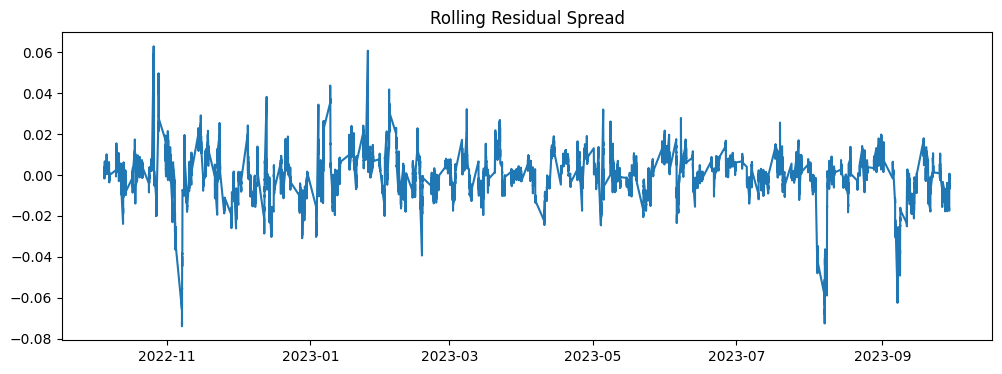

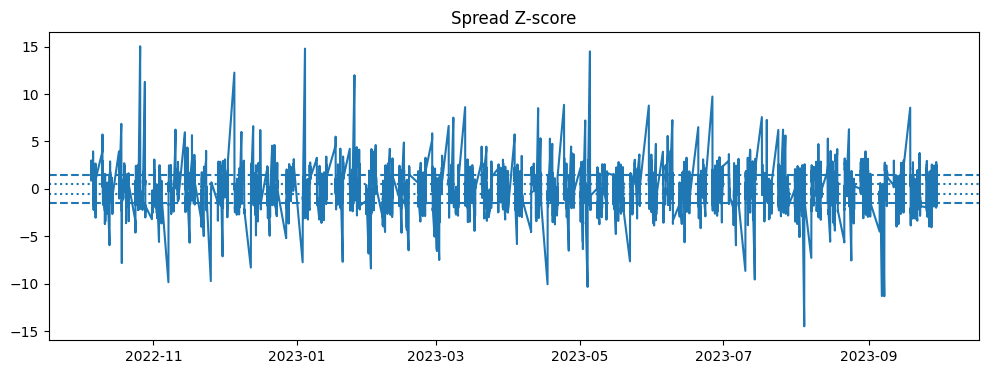

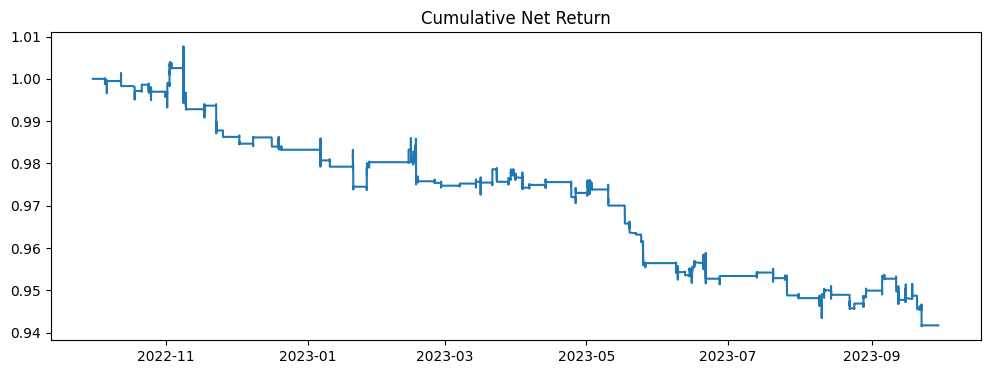

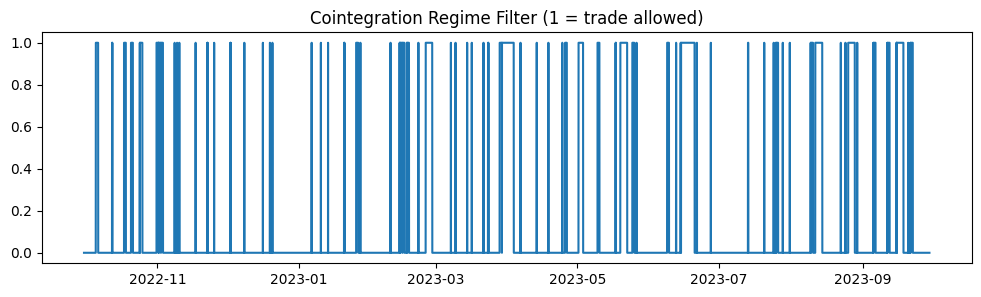

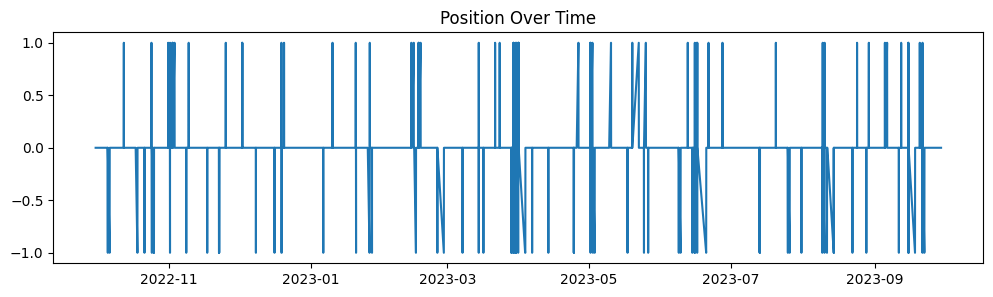

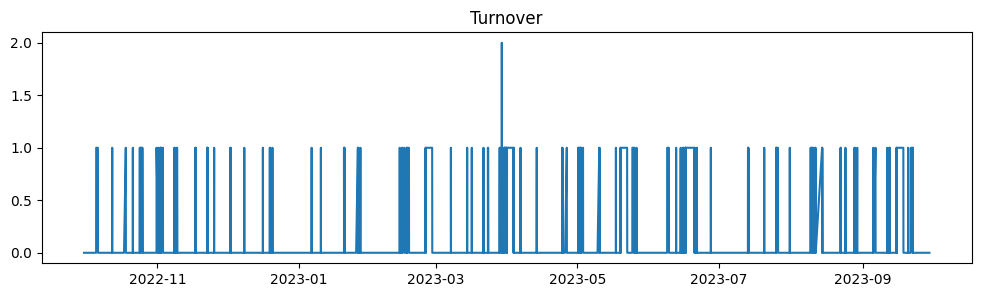

In [95]:
# plots
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["spread"])
plt.title("Rolling Residual Spread")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["zscore"])
plt.axhline(entry_z, linestyle="--")
plt.axhline(-entry_z, linestyle="--")
plt.axhline(exit_z, linestyle=":")
plt.axhline(-exit_z, linestyle=":")
plt.title("Spread Z-score")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["cum_ret_net"])
plt.title("Cumulative Net Return")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(df.index, df["coint_ok"])
plt.title("Cointegration Regime Filter (1 = trade allowed)")
plt.show()

# extra diagnostics plots
plt.figure(figsize=(12, 3))
plt.plot(df.index, df["position"])
plt.title("Position Over Time")
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(df.index, df["turnover"])
plt.title("Turnover")
plt.show()

In [97]:
# holding-period diagnostics
df["pos_change"] = df["position"].ne(df["position"].shift())
segment_id = df["pos_change"].cumsum()

holding_lengths = df[df["position"] != 0].groupby(segment_id).size()

if len(holding_lengths) > 0:
    print("Average holding bars:", holding_lengths.mean())
    print("Median holding bars:", holding_lengths.median())
    print("Max holding bars:", holding_lengths.max())
else:
    print("No active trades found.")

Average holding bars: 37.863013698630134
Median holding bars: 29.5
Max holding bars: 186
